In [4]:
%pip install -r requirements-estimation.txt
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
from eep153_tools.sheets import read_sheets
import pandas as pd
import numpy as np
from cfe import Regression

## Senegal Data set-up

In [7]:
Senegal_URL = "https://docs.google.com/spreadsheets/d/1s01A3lSZdlcHQPIfJcLdI3k-NtQkTInia1fDAg7W5eQ/edit?gid=1254962063#gid=1254962063"

In [8]:
# modified spreadsheet, includes FCT and RDI
Senegal_URL_1 = "https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/edit?gid=1254962063#gid=1254962063"

In [66]:
SE_fct = read_sheets(Senegal_URL_1,sheet='FCT')

SE_fct = SE_fct.set_index('j')
SE_fct.columns.name = 'n'

SE_fct = SE_fct.apply(lambda x: pd.to_numeric(x,errors='coerce'))

In [46]:
rdi = read_sheets(Senegal_URL_1,sheet='RDI')

rdi = rdi.set_index('n')
rdi.columns.name = 'k'

rdi = rdi.apply(lambda x: pd.to_numeric(x,errors='coerce'))

rdi = rdi.rename(columns={'F 00-03':'Females 00-03', 'M 00-03':'Males 00-03',
                    'F 04-08':'Females 04-08', 'M 04-08':'Males 04-08',
                    'F 09-13':'Females 09-13', 'M 09-13':'Males 09-13',
                    'F 14-18': 'Females 14-18', 'M 14-18':'Males 14-18',
                    'F 19-30':'Females 19-30', 'M 19-30':'Males 19-30',
                    'F 31-50':'Females 31-50', 'M 31-50':'Males 31-50',
                    'F 51+':'Females 51+','M 51+':'Males 51+'})

In [47]:
rdi.head()

k,Females 00-03,Males 00-03,Females 04-08,Males 04-08,Females 09-13,Males 09-13,Females 14-18,Males 14-18,Females 19-30,Males 19-30,Females 31-50,Males 31-50,Females 51+,Males 51+
n,,,,,,,,,,,,,,
Energy,1000.0,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
Fiber,14.0,14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
Folate,150.0,150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
Calcium,700.0,700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0


In [22]:
def prepare_data(URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(URL, sheet = FE_Sheet)
    d = read_sheets(URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = np.log(x)

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

In [23]:
S18_y, S18_d = prepare_data(Senegal_URL, "Food Expenditures (2018)")
S19_y, S19_d = prepare_data(Senegal_URL, "Food Expenditures (2019)")

SE_y = pd.concat([S18_y, S19_y])
SE_d = pd.concat([S18_d, S19_d])

In [24]:
SE_y = SE_y.stack().dropna()
SE_d = SE_d.stack().dropna()

SE_y = SE_y.groupby(level=['i', 't', 'm', 'j']).first()
SE_d = SE_d.groupby(level=['i', 't', 'm', 'k']).first()

assert SE_y.index.names == ['i','t','m','j']
assert SE_d.index.names == ['i','t','m','k']

In [15]:
SE_result = Regression(y = SE_y,d = SE_d)
SE_result.predicted_expenditures()

i       t     m        j                                                                  
112     2018  dakar    Ail                                                                     577.701198
                       Arachides décortiquées ou pilées (noflaye)                              396.552597
                       Arôme (Maggi, Jumbo, etc.)                                              183.316015
                       Aubergine, Courge/Courgette                                             238.542067
                       Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     150.336375
                                                                                                 ...     
259812  2019  sedhiou  Thé                                                                     147.491146
                       Tomate fraîche                                                          124.069691
                       Viande de b__uf                       

In [25]:
SE_xhat = SE_result.predicted_expenditures()

In [26]:
SE_prices18 = read_sheets(Senegal_URL, sheet="Food Prices (2018)")
SE_prices19 = read_sheets(Senegal_URL, sheet="Food Prices (2019)")

SE_prices = pd.concat([SE_prices18, SE_prices19])

SE_prices['t'] = SE_prices['t'].astype(str).str.strip()
SE_prices['m'] = SE_prices['m'].astype(str).str.strip().str.lower()
SE_prices['j'] = SE_prices['j'].astype(str).str.strip()
SE_prices['Price'] = pd.to_numeric(SE_prices['Price'], errors='coerce')

SE_prices = SE_prices.pivot_table(
    index=['t', 'm'],
    columns='j',
    values='Price',
    aggfunc='mean'
)

SE_pbar = SE_prices.xs('2019', level='t').mean()
SE_pbar = SE_pbar.reindex(SE_result.beta.index).dropna()

SE_pbar

j
Ail                                                                     277.107143
Arachides décortiquées ou pilées (noflaye)                              304.270833
Arôme (Maggi, Jumbo, etc.)                                              244.642857
Aubergine, Courge/Courgette                                             149.702381
Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     193.630952
                                                                          ...     
Thé                                                                     483.556548
Tomate fraîche                                                          195.541383
Viande de b__uf                                                        2316.071429
Viande de poulet                                                       2716.071429
Vinaigre /moutarde                                                      297.088176
Length: 63, dtype: float64

In [27]:
# Total food expenditures per household
SE_xbar = SE_xhat.groupby(['i', 't', 'm']).sum()

# Reference budget: median household
SE_xref = SE_xbar.quantile(0.5)

In [28]:
SE_qhat = (SE_xhat.unstack('j')/SE_pbar).dropna(how='all')

# Drop missing columns
SE_qhat = SE_qhat.loc[:,SE_qhat.count()>0]

SE_qhat

,,j,Ail,Arachides décortiquées ou pilées (noflaye),"Arôme (Maggi, Jumbo, etc.)","Aubergine, Courge/Courgette",Autre légumes frais n.d.a (y compris les fleurs blanches de bissap),Autres condiments (poivre etc.),"Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)","Autres poissons fumés (kong fumé, yaboy ou obo fumé)","Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)",Banane douce,...,Riz local entier,"Salade (laitue, batavia, etc.)",Sel,Soumbala (netetou),Sucre (poudre ou morceaux),Thé,Tomate fraîche,Viande de b__uf,Viande de poulet,Vinaigre /moutarde
i,t,m,,,,,,,,,,,,,,,,,,,,,
112,2018,dakar,2.084758,1.303288,0.749321,1.593442,0.776407,0.176746,5.333878,2.624926,1.818128,2.364299,...,5.945752,1.542816,0.697593,0.641896,3.527760,0.674189,1.991816,1.709252,2.107129,2.429100
131,2018,dakar,5.580223,2.151579,1.146537,3.045044,1.220664,0.370097,11.144877,5.602622,2.236189,3.964978,...,21.048222,2.438960,1.308624,1.164136,10.180226,1.097838,3.321805,3.085724,3.844538,6.251501
132,2018,dakar,1.339475,1.142151,0.557890,1.236628,0.622344,0.126869,3.266468,2.015133,1.552278,2.148571,...,4.487358,1.560591,0.560093,0.503000,2.512880,0.572935,1.477639,1.508072,1.895797,1.574222
134,2018,dakar,0.738100,0.945625,0.494252,0.888483,0.417536,0.091490,2.175845,1.684989,1.041750,1.653685,...,2.426984,1.536411,0.379059,0.436894,1.658613,0.386047,1.022310,1.378272,1.583611,0.893630
135,2018,dakar,0.968318,1.185393,0.487001,1.147001,0.466799,0.105889,2.175192,1.465371,1.029669,1.736006,...,2.234303,1.709164,0.554309,0.508546,2.309790,0.517583,1.224106,1.494656,1.704598,1.161053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259611,2019,sedhiou,0.078518,0.704834,1.093409,0.324947,0.583397,0.020936,0.183166,0.358649,0.786082,0.409335,...,0.930905,1.564183,0.371177,0.151883,0.336336,0.171990,0.280434,0.746242,1.002186,0.139484
259612,2019,sedhiou,0.392179,1.619725,2.416232,0.988102,1.301839,0.078176,0.797917,0.722716,1.461185,0.736760,...,6.786834,2.921854,1.097381,0.402553,1.877109,0.355902,0.849507,1.524038,2.046558,0.748308
259810,2019,sedhiou,0.293976,0.965769,1.965036,0.633457,1.251598,0.054073,0.720370,0.978882,1.223001,0.618530,...,2.838974,1.973375,0.558299,0.264728,0.908866,0.272450,0.691981,1.109915,1.493045,0.472051


# Nutrient Demand #

In [67]:
SE_fct.head()

n,j_eng,WAFCT_Code,FDCID,Energy,Protein,Carbohydrate,Fiber,Calcium,Iron,Zinc,Vitamin A,Thiamin,Riboflavin,Niacin,Vitamin B-6,Folate,Vitamin B-12,Vitamin C,Notes
j,,,,,,,,,,,,,,,,,,,
Ail,NaN,NaN,2512377.0,357,0.92,87.3,4.8,75.0,3.99,0.41,0.0,0.051,0.068,0.6,0.05,0.0,0.0,0.0,NaN
Beurre,NaN,NaN,NaN,519,12.10,55.4,0.0,358.0,9.30,3.90,467.0,0.520,0.780,3.9,0.33,39.0,1.0,43.0,NaN
Café,NaN,NaN,NaN,62,3.90,19.8,42.9,1244.0,13.70,3.56,286.0,0.100,0.150,6.1,1.50,300.0,0.0,19.0,NaN
Carotte,NaN,NaN,NaN,37,4.40,1.7,4.9,258.0,4.90,0.56,407.0,0.200,0.370,2.1,0.24,120.0,0.0,57.0,NaN
Choux,NaN,NaN,NaN,174,20.30,0.0,0.0,11.0,1.20,3.43,0.0,0.110,0.110,8.4,0.23,13.0,1.8,0.0,NaN


In [68]:
SE_fct,SE_c0 = SE_fct.align(SE_qhat.T,axis=0,join='inner')
print(SE_fct.index)

Index(['Ail', 'Beurre', 'Café', 'Carotte', 'Choux', 'Citrons',
       'Concentré de tomate', 'Cube alimentaire (Maggi, Jumbo, )',
       'Feuilles d'oseille (bissap)',
       'Huile de soja / végétale (e.g., Ninaal, Jaara, etc.)',
       'Lait en poudre', 'Oignon frais', 'Piment', 'Pomme de terre',
       'Pâte d'arachide', 'Riz local brisé', 'Sel',
       'Sucre (poudre ou morceaux)', 'Thé', 'Viande de poulet',
       'Arachides décortiquées ou pilées (noflaye)', 'Huile de palme rouge',
       'Manioc', 'Mayonnaise', 'Oeufs',
       'Poisson frais yaboy ou obo (sardinelle)',
       'Salade (laitue, batavia, etc.)', 'Soumbala (netetou)',
       'Tomate fraîche', 'Vinaigre /moutarde',
       'Autres condiments (poivre etc.)', 'Lait caillé, yaourt',
       'Poivron frais',
       'Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)',
       'Poisson séché (tambadiang, kong, etc.)', 'Pâtes alimentaires',
       'Aubergine, Courge/Courgette', 'Chocolat à croquer, pâte à tar

In [69]:
SE_N = SE_fct.T@SE_c0
SE_N = SE_N.dropna() 
SE_N.head()

i,112,131,132,134,135,136,139,151,152,153,...,259211,259410,259411,259412,259610,259611,259612,259810,259811,259812
t,2018,2018,2018,2018,2018,2018,2018,2018,2018,2018,...,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019
m,dakar,dakar,dakar,dakar,dakar,dakar,dakar,dakar,dakar,dakar,...,sedhiou,sedhiou,sedhiou,sedhiou,sedhiou,sedhiou,sedhiou,sedhiou,sedhiou,sedhiou
n,,,,,,,,,,,,,,,,,,,,,
Energy,30714.676945,71272.535997,24007.240284,18462.438284,22037.904183,23733.480373,11521.460148,53684.796504,26658.867277,20776.485389,...,22030.673146,20950.627044,12319.748706,9624.676102,10517.020016,8167.261057,23362.367605,14355.719448,18889.212122,16403.885596
Protein,1348.875645,2804.218570,1089.411605,847.288136,975.256723,1044.635777,558.095415,2146.696666,1241.236527,967.902296,...,928.111254,919.901341,568.634579,456.046694,496.956700,402.769055,1025.584624,679.283746,871.626284,722.471486
Carbohydrate,3082.978731,7081.374249,2326.428478,1713.981829,2087.162767,2376.375338,990.050486,5500.225719,2363.473955,1896.516703,...,1761.676354,1782.345400,879.442013,684.345372,785.015137,553.450454,1759.855064,1123.491581,1377.759428,1221.007040
Fiber,822.813322,1937.677941,608.384865,449.574459,540.169192,601.853491,244.151309,1522.424096,631.738095,483.247180,...,438.712874,458.534747,223.197941,169.945545,195.848245,136.624551,451.439654,283.681768,360.494650,296.152346
Calcium,25177.519452,49469.619289,20199.789150,15500.522099,17306.720684,18868.625574,10059.679760,38407.833781,23770.126554,17513.259726,...,14615.211240,15382.123487,7936.416821,7493.628026,8004.502456,6125.950317,15007.122742,11037.093808,12840.256879,10635.516284


In [53]:
rdi.columns

Index(['Females 00-03', 'Males 00-03', 'Females 04-08', 'Males 04-08',
       'Females 09-13', 'Males 09-13', 'Females 14-18', 'Males 14-18',
       'Females 19-30', 'Males 19-30', 'Females 31-50', 'Males 31-50',
       'Females 51+', 'Males 51+'],
      dtype='str', name='k')

In [70]:
SE_result.d[rdi.columns].mean().sum()

KeyError: "['Females 51+', 'Males 51+'] not in index"

In [43]:
rdi.head()

k,Females 00-03,Males 00-03,Females 04-08,Males 04-08,Females 09-13,Males 09-13,Females 14-18,Males 14-18,Females 19-30,Males 19-30,Females 31-50,Males 31-50,Females 51+,Males 51+
n,,,,,,,,,,,,,,
Energy,1000.0,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
Fiber,14.0,14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
Folate,150.0,150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
Calcium,700.0,700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0


In [38]:
# average nutrient consumption per household
# in Senegal, the average household is approximately 8 people
SE_N_summary = SE_N.mean(axis=1).to_frame("Average Nutrient Consumption")
SE_N_summary

,Average Nutrient Consumption
n,
Energy,16428.148529
Protein,695.497612
Carbohydrate,1433.863964
Fiber,365.125512
Calcium,11834.187316
Iron,193.915421
Zinc,111.444989
Vitamin A,17768.323584
Thiamin,9.238105


In [74]:
SE_dbar = SE_result.d[rdi.columns].mean()

KeyError: "['Females 51+', 'Males 51+'] not in index"

In [75]:
# This matrix product gives minimum nutrient requirements for
# the average household
SE_hh_rdi = rdi@SE_dbar
SE_hh_rdi

NameError: name 'SE_dbar' is not defined

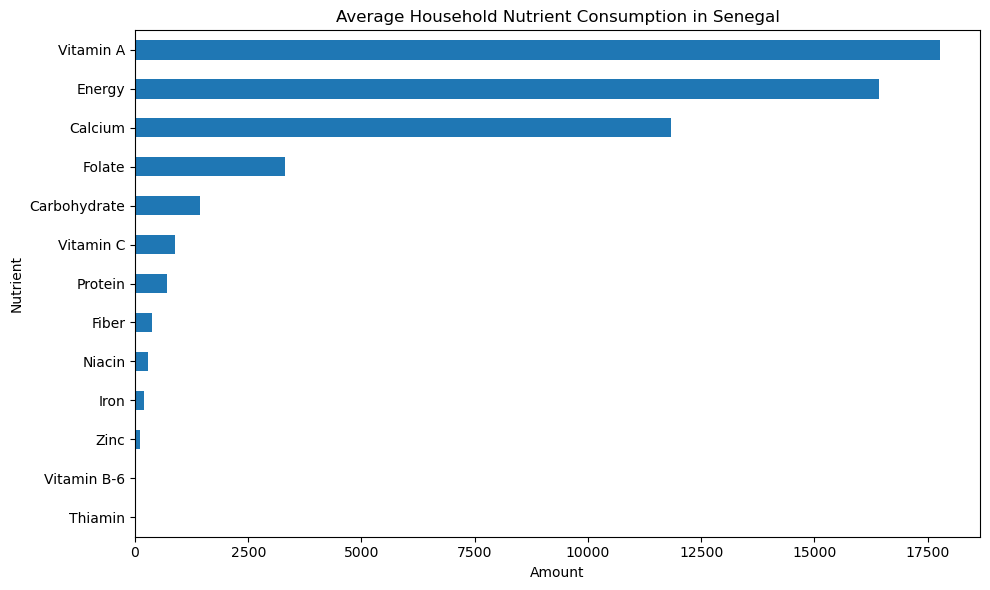

In [58]:
import matplotlib.pyplot as plt

# average across households
SE_N_summary = SE_N.mean(axis=1)

plt.figure(figsize=(10,6))
SE_N_summary.sort_values().plot(kind='barh')

plt.title("Average Household Nutrient Consumption in Senegal")
plt.xlabel("Amount")
plt.ylabel("Nutrient")

plt.tight_layout()
plt.show()

In [56]:
SE_N_region = SE_N.T.groupby(level='m').mean().T

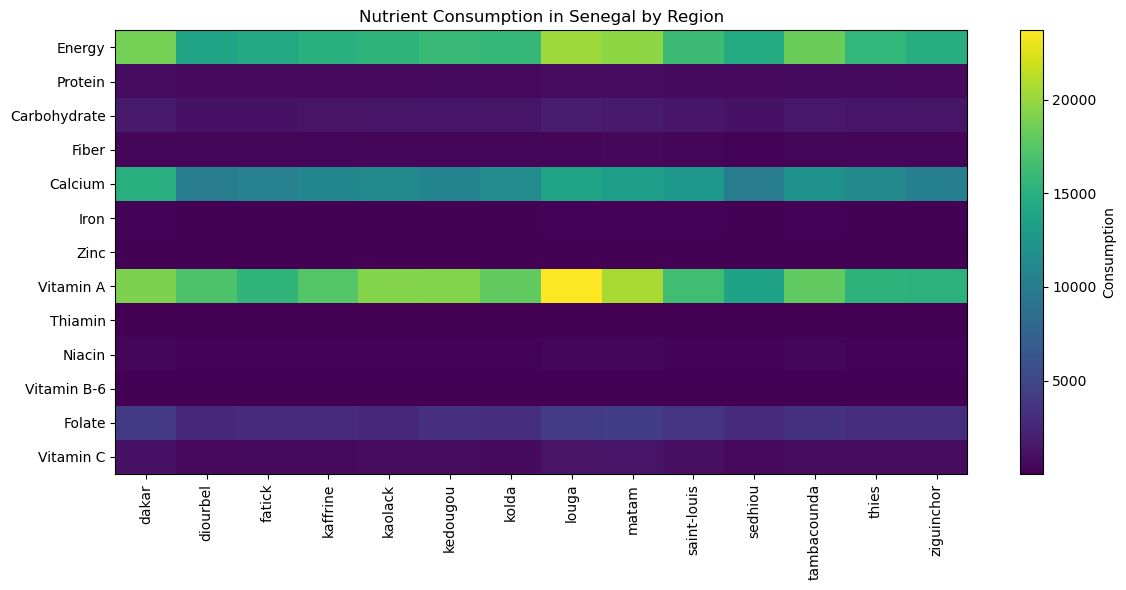

In [57]:
plt.figure(figsize=(12,6))
plt.imshow(SE_N_region, aspect='auto')

plt.colorbar(label='Consumption')
plt.yticks(range(len(SE_N_region.index)), SE_N_region.index)
plt.xticks(range(len(SE_N_region.columns)), SE_N_region.columns, rotation=90)

plt.title("Nutrient Consumption in Senegal by Region")

plt.tight_layout()
plt.show()

In [59]:
def nutrient_demand(x,p,r,fct):
    c = r.demands(x,p)
    fct0,c0 = fct.align(c,axis=0,join='inner')
    N = fct0.T@c0

    # Drop duplicate nutrient rows (keeps first).  If your FCT has
    # duplicates this silently discards data; worth checking with
    # fct.index[fct.index.duplicated()] to see what's being dropped.
    N = N.loc[~N.index.duplicated()]

    return N

Text(0, 0.5, 'log nutrient')

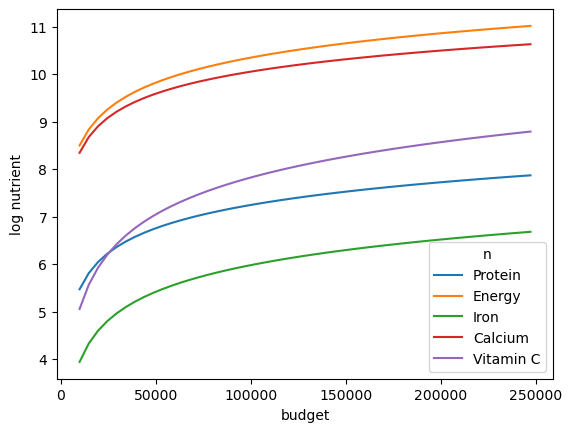

In [71]:
X = np.linspace(SE_xref/5,SE_xref*5,50)

UseNutrients = ['Protein','Energy','Iron','Calcium','Vitamin C']

df = pd.concat({myx:np.log(nutrient_demand(myx,SE_pbar,SE_result,SE_fct))[UseNutrients] for myx in X},axis=1).T
ax = df.plot()

ax.set_xlabel('budget')
ax.set_ylabel('log nutrient')